In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path(".").resolve()))
from analysis_helpers import analyse_wer_within, analyse_wer_across, find_transcript_files

In [3]:
PARTICIPANT_DIR = Path("data") / "experiment_Riri_1779974812966"

# experiment_Gerard_1780157613344
# experiment_Riri_1779974812966
# experiment_Albert Barreiro_1779785968775

transcripts = {
    "temp0": find_transcript_files(PARTICIPANT_DIR, "temp0"),
    "temp1": find_transcript_files(PARTICIPANT_DIR, "temp1"),
    "asr":   find_transcript_files(PARTICIPANT_DIR, "asr"),
    "human":   find_transcript_files(PARTICIPANT_DIR, "human"),
}

In [4]:
transcripts["temp0"]

[PosixPath('data/experiment_Riri_1779974812966/analysis/transcript_experiment_temp0_take1.json'),
 PosixPath('data/experiment_Riri_1779974812966/analysis/transcript_experiment_temp0_take2.json'),
 PosixPath('data/experiment_Riri_1779974812966/analysis/transcript_experiment_temp0_take3.json'),
 PosixPath('data/experiment_Riri_1779974812966/analysis/transcript_experiment_temp0_take4.json'),
 PosixPath('data/experiment_Riri_1779974812966/analysis/transcript_experiment_temp0_take5.json')]

In [5]:
def compute_wer_data(normalize_text):
    methods = {
        "gemini_temp0": analyse_wer_within(transcripts["temp0"], "temperature=0", normalize_text=normalize_text),
        "gemini_temp1": analyse_wer_within(transcripts["temp1"], "temperature=1", normalize_text=normalize_text),
        "asr": analyse_wer_within(transcripts["asr"], "asr", normalize_text=normalize_text),
        "asr_vs_gemini_temp0": analyse_wer_across(
            transcripts["temp0"], transcripts["asr"], "asr vs temperature=0", normalize_text=normalize_text
        ),
        "asr_vs_human": analyse_wer_across(
            transcripts["human"], transcripts["asr"], "asr vs human", normalize_text=normalize_text
        ),
        "gemini_temp0_vs_human": analyse_wer_across(
            transcripts["human"], transcripts["temp0"], "temperature=0 vs human", normalize_text=normalize_text
        ),
    }
    return {k: v for k, v in methods.items() if v is not None}


wer_data_normalized = compute_wer_data(normalize_text=True)
wer_data_raw = compute_wer_data(normalize_text=False)

  ⚠️  Schema violation: field is 'text_original' instead of 'text'. Using its content as fallback.
  ⚠️  Schema violation: field is 'text_original' instead of 'text'. Using its content as fallback.


In [ ]:
# ── Design tokens (validated default palette) ────────────────────────────────
C_TEMP0   = "#2a78d6"   # blue   — slot 1
C_TEMP1   = "#1baf7a"   # aqua   — slot 2
C_ASR     = "#eda100"   # yellow — slot 3
C_CROSS   = "#008300"   # green  — slot 4
SURFACE   = "#fcfcfb"
GRIDLINE  = "#e1e0d9"
MUTED     = "#898781"
PRIMARY   = "#0b0b0b"
SECONDARY = "#52514e"

METRIC_KEY   = "mean_wer"
METRIC_LABEL = "Mean WER"

METHODS = ["gemini_temp0", "gemini_temp1", "asr", "asr_vs_gemini_temp0", "asr_vs_human", "gemini_temp0_vs_human"]
LABELS  = ["gemini temp=0", "gemini temp=1", "ASR (pyannote+Qwen)", "ASR vs gemini temp=0", "ASR vs human", "gemini temp=0 vs human"]
COLORS  = [C_TEMP0, C_TEMP0, C_TEMP0, C_ASR, C_TEMP1, C_TEMP1]


def plot_wer(wer_data, title):
    keys, labels, colors = [], [], []
    for method, label, color in zip(METHODS, LABELS, COLORS):
        if method in wer_data:
            keys.append(method)
            labels.append(label)
            colors.append(color)

    vals  = [wer_data[k][METRIC_KEY] * 100 for k in keys]
    x     = np.arange(len(keys))
    y_max = 15#max(vals) if vals else 0.1

    fig, ax = plt.subplots(figsize=(5, 5), facecolor=SURFACE)

    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    bars = ax.bar(x, vals, width=0.6, color=colors, linewidth=0)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.025,
            f"{v:.1f}%",
            ha="center", va="bottom",
            fontsize=8, color=SECONDARY,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9, color=MUTED)
    ax.tick_params(axis="y", labelsize=9, labelcolor=MUTED, length=0)
    ax.tick_params(axis="x", length=0)
    ax.set_ylim(0, y_max * 1.3 if y_max else 1)
    ax.set_ylabel("WER (%)", fontsize=9, color=MUTED, labelpad=6)
    ax.set_title(f"{title}\n{METRIC_LABEL}", fontsize=11, color=PRIMARY, pad=10)

    plt.show()

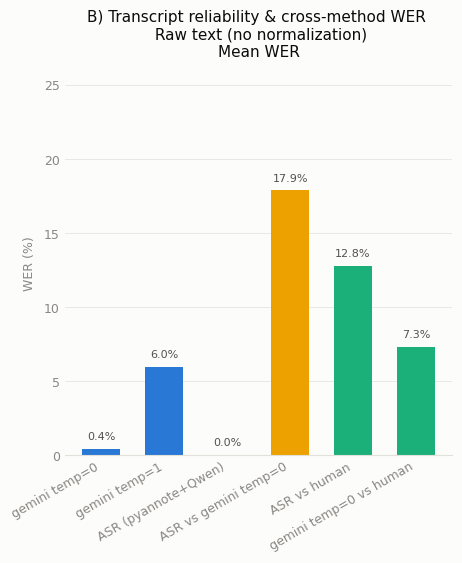

In [7]:
plot_wer(
    wer_data_raw,
    "B) Transcript reliability & cross-method WER \n Raw text (no normalization)",
)

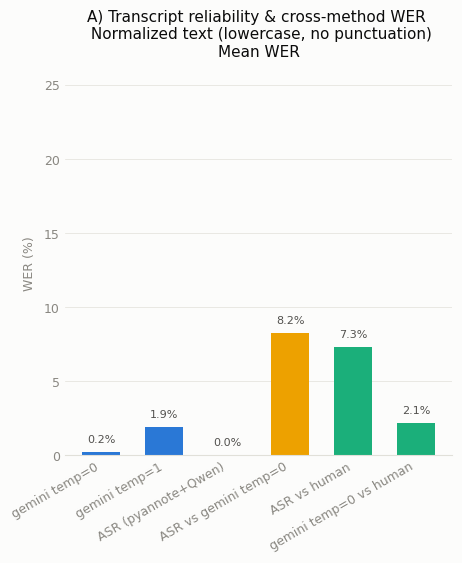

In [8]:
plot_wer(
    wer_data_normalized,
    "A) Transcript reliability & cross-method WER \n Normalized text (lowercase, no punctuation)",
)